In [ ]:
import torch
from PIL import Image
from ncut_pytorch import ncut_fn
path1 = "./images/for_kate/orange_cat.jpg"
image1 = Image.open(path1).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")

from extract_features import extract_dino_features, dino_image_transform
from dino_correspondence import _kway_cluster_single_image
dino_image_embeds = extract_dino_features(dino_image_transform(image1).unsqueeze(0))
n_clusters = 2
dino_image_embeds = dino_image_embeds.reshape(-1, dino_image_embeds.shape[-1])
kway_eigvec = _kway_cluster_single_image(dino_image_embeds, n_clusters=n_clusters, gamma=None)

Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


In [54]:
print(kway_eigvec.shape)

torch.Size([1025, 2])


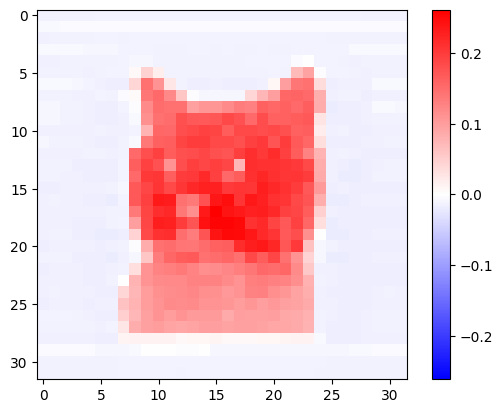

In [46]:
import matplotlib.pyplot as plt
eigvec = kway_eigvec[1:, 1]

arr = eigvec.reshape(32, 32).cpu()
max_abs = arr.abs().max().item()
plt.imshow(arr.numpy(), cmap='bwr', vmin=-max_abs, vmax=max_abs)
plt.colorbar()
plt.show()

In [7]:
fg_idx = kway_eigvec.max(0).values.argmax().item()
print(fg_idx)
fg_mask = kway_eigvec.argmax(-1) == fg_idx
print(fg_mask.shape)

0
torch.Size([1025])


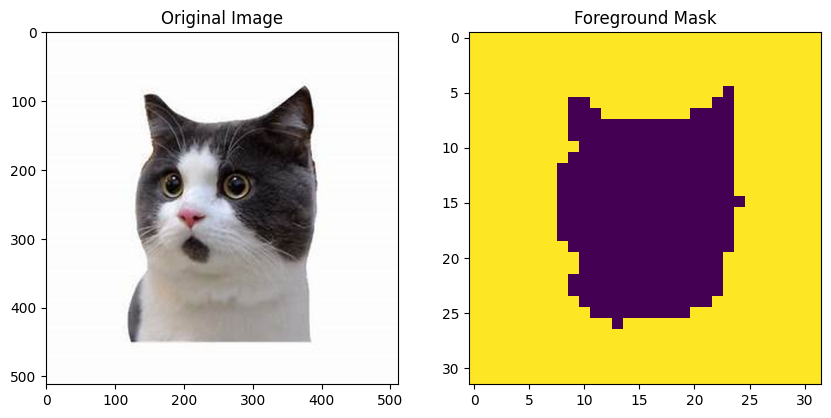

In [8]:
fg_mask = fg_mask[1:].reshape(32, 32)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(image1)
axes[1].imshow(fg_mask)
axes[0].set_title('Original Image')
axes[1].set_title('Foreground Mask')
plt.show()